In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
from scipy import signal;
from scipy.interpolate import interp1d;

In [3]:
# Test inputs - delete when done!
delta_t = reader.fetch_data_from_h5("C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D");

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sethx\AppData\Local\Temp\ipykernel_27756\2932329221.py:22: SyntaxWarning: invalid escape sequence '\d'
  plt.title("GAM damping & RH residual relaxation (q = 3.5, $\delta$ = -0.3)");


[0.000e+00 2.000e+00 4.000e+00 ... 2.996e+03 2.998e+03 3.000e+03]


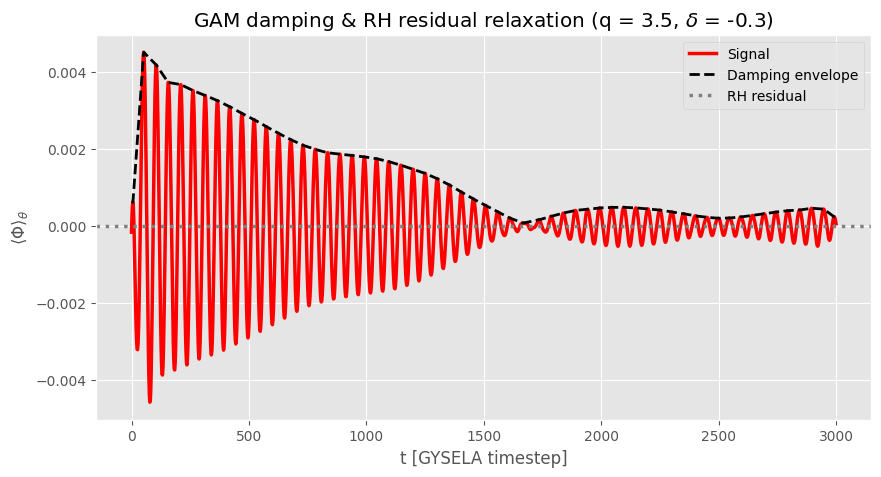

In [ ]:
def plot_rosenbluth_hinton(phi2D_list, radial_index, delta_t, dt_diag, signal_band_pass = True):
	# Signal isolation and data processing.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list)[:, radial_index].values;
	stride = utils.calculate_stride(delta_t, dt_diag);

	if signal_band_pass:
		radial_time_series = utils.butterworth_band_pass_filter(radial_time_series, delta_t, 0.0005, 0.0025, stride);

	# We recover the actual number of simulation time-steps here.
	# This does not actually change the size of the array, only its spacing.
	time_range = np.arange(len(radial_time_series)) * stride;
	GAM_frequency = utils.extract_gam_frequency(phi2D_list, delta_t, radial_index);
	amplitude_envelope, residual_level = utils.generate_residual_envelope(radial_time_series, GAM_frequency, dt_diag);

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range[:], radial_time_series[:], color = "red", lw = 2.5, label = "Signal");
	plt.plot(time_range[:], amplitude_envelope[:], color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = f"RH residual", lw = 2.5);
	plt.xlabel("t [GYSELA timestep]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.title("GAM damping & RH residual relaxation (q = 3.5, $\delta$ = -0.3)");
	plt.legend(frameon = True, loc = "upper right");
	plt.show();

plot_rosenbluth_hinton(data_arrays, 180, delta_t, 50);